# Social Media Sentiment Analysis

This notebook processes a dataset of Twitter telemetry to compare the classification performance of zero-shot lexicon analyzers (VADER, TextBlob) against a trained Logistic Regression model. The pipeline includes data ingestion, text normalization, exploratory data analysis via word frequency and cross-model evaluation.

In [6]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
import nltk
from nltk.corpus import stopwords
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_predict

pd.set_option('display.max_colwidth', None)

## Loading the data

Let's load the data into a single dataframe.

In [9]:
dftrain = pd.read_csv("train.csv", encoding='latin1')
dftest = pd.read_csv("test.csv", encoding='latin1')
df = pd.concat([dftrain, dftest])
df # Sneak peek

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797.0,27400.0,105.0
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265.0,470.0,164.0
4,358bd9e861,"Sons of ****, why couldn`t they put them on the releases we already bought","Sons of ****,",negative,noon,60-70,Angola,32866272.0,1246700.0,26.0
...,...,...,...,...,...,...,...,...,...,...
4810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The dataset contains demographic metadata. For our objective we will drop them and isolate the `text` and `sentiment` columns.

In [11]:
df.drop(columns=[col for col in df.columns if col not in ['text', 'sentiment']], inplace=True)

Handling missing values.

In [13]:
df.isnull().sum()

text         1282
sentiment    1281
dtype: int64

We identify missing values in the target and feature columns. Synthetic imputation is impossible for raw unstructured text, so these records are dropped.

In [15]:
df.dropna(inplace=True)

## Data Preprocessing

Social media text requires aggressive normalization before vectorization. The following function performs regex-based cleaning. Crucially, we augment the standard `NLTK` English stopwords with Twitter-specific noise tokens derived from domain experience.

In [18]:
nltk.download('stopwords')
stop = set(stopwords.words('english'))
stop.update({'u', 'x', 'ur', 'im', }) # Adding my own from experience

def preprocessor(text):
    text = text.lower() # Convert all to lowercase
    text = re.sub(r'http\S+|www\S+', ' ', text) # Remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text) # Remove non-alphanumeric characters (keep spaces though)

    # Remove stopwords
    ret_text = ""
    for word in text.split():
        if word not in stop:
            ret_text += word + " "
            
    ret_text = re.sub(r'\s+', ' ', ret_text).strip() # Remove extra whitespace

    if len(ret_text) == 0: # Check if we cleaned it dead to drop it later
        ret_text = np.nan
        
    return ret_text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nicklamda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Let's keep the original text, just in case, and apply the cleaning.

In [20]:
df['dirty_text'] = df['text'].copy()
df['text'] = df['dirty_text'].apply(preprocessor)
df.isnull().sum()

text          105
sentiment       0
dirty_text      0
dtype: int64

Records that were reduced to empty strings during the aggressive cleaning phase are dropped. Below is a sample comparing the raw telemetry to the normalized text ready for modeling.

In [22]:
df.dropna(inplace=True) 
df[['dirty_text', 'text']].sample(n=10, random_state=42)

,dirty_text,text
2165,fantastic day in the AZ sun,fantastic day az sun
19740,"_x hah, well at least we are not saying; tory is a fatty watty",hah well least saying tory fatty watty
3893,"1st- TY to those who follow back. 2nd - grrr to those who don`t, cuz it messes up being able to follow others u want to when ur at 2000+",st ty follow back nd grrr cuz messes able follow others want
22762,"Working late at night on a Dell notebook, Dell`s quality has gone down hill, warrenty service sucks too, poor people buy a Mac instead",working late night dell notebook dell quality gone hill warrenty service sucks poor people buy mac instead
11514,My pleasure. Hear Kelli has new project! #followfriday,pleasure hear kelli new project followfriday
229,sorry for my lack of tweets ive been buzy. new vid this saturday!!,sorry lack tweets ive buzy new vid saturday
9667,thanx for showin luv,thanx showin luv
20593,just watching ncis complete first season,watching ncis complete first season
21305,I was rooting for Betty.,rooting betty
2810,"Ooo showing of your French skills!! lol Things good over here. Lovely weather, so should be outside How`s u?",ooo showing french skills lol things good lovely weather outside


## Exploratory Data Analysis

Let's first just check to see all sentiments are correctly labeled and their value counts.

In [25]:
df['sentiment'].value_counts()

sentiment
neutral     12450
positive     9682
negative     8777
Name: count, dtype: int64

We begin by examining the class distribution. As expected in raw social media telemetry, the dataset exhibits a heavy skew toward 'neutral' statements. To understand the domain-specific vocabulary driving the polarized classes, we render Word Clouds for both positive and negative subsets.

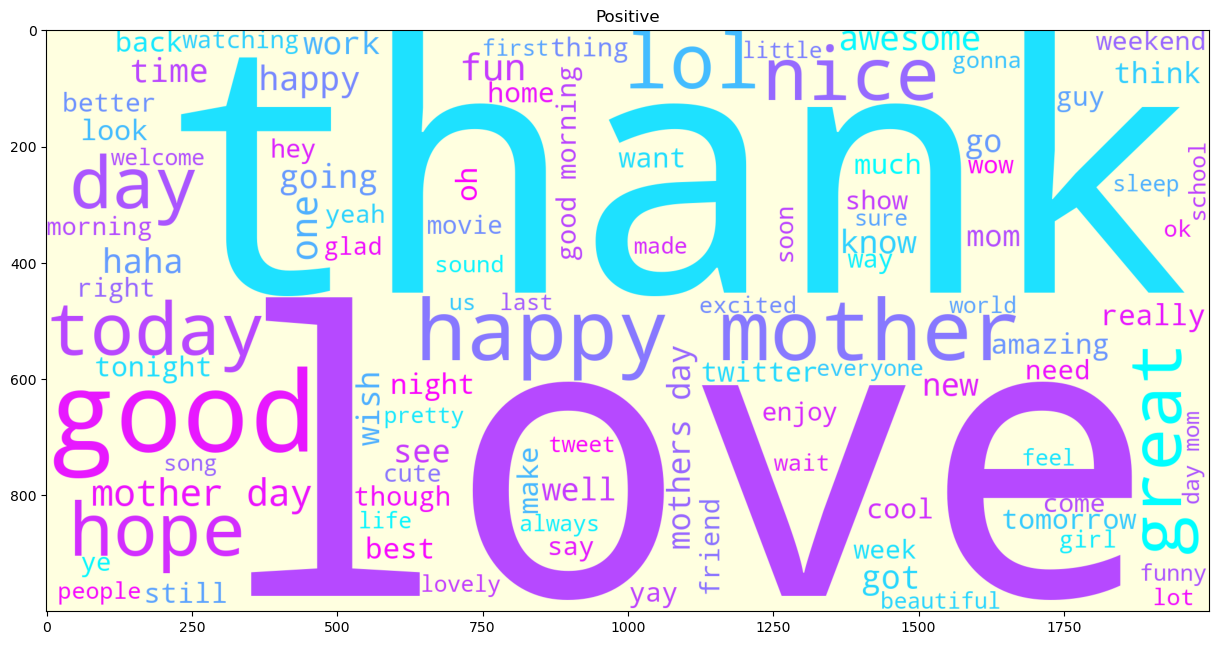

In [27]:
# For positive sentiments
WordCloud()
positive_df = df[df['sentiment']=='positive']
positive_list = positive_df['text'].tolist()
positive_string = " ".join(positive_list)
wordcloud = WordCloud(width=2000,
                      height=1000,
                      background_color='lightyellow',
                      colormap = 'cool',
                      max_words = 100).generate(positive_string)

plt.figure(figsize=(15,9))
plt.imshow(wordcloud)
plt.title("Positive")
plt.show()

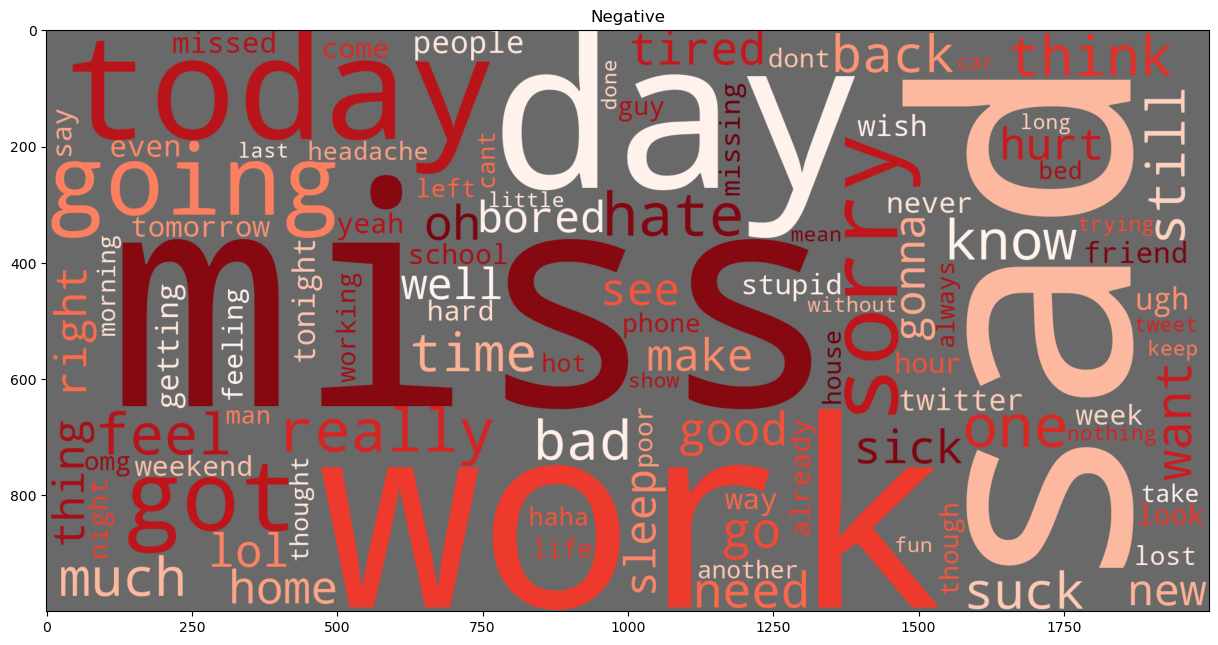

In [28]:
# For negative sentiments
WordCloud()
negative_df = df[df['sentiment']=='negative']
negative_list = negative_df['text'].tolist()
negative_string = " ".join(negative_list)
wordcloud = WordCloud(width=2000,
                      height=1000,
                      background_color='dimgray',
                      colormap = 'Reds',
                      max_words = 100).generate(negative_string)

plt.figure(figsize=(15,9))
plt.imshow(wordcloud)
plt.title("Negative")
plt.show()

Does verbosity correlate with polarity? We choose a violin plot to examine the density and distribution of text length across the three sentiment classes, looking for structural patterns that might inform downstream feature engineering.

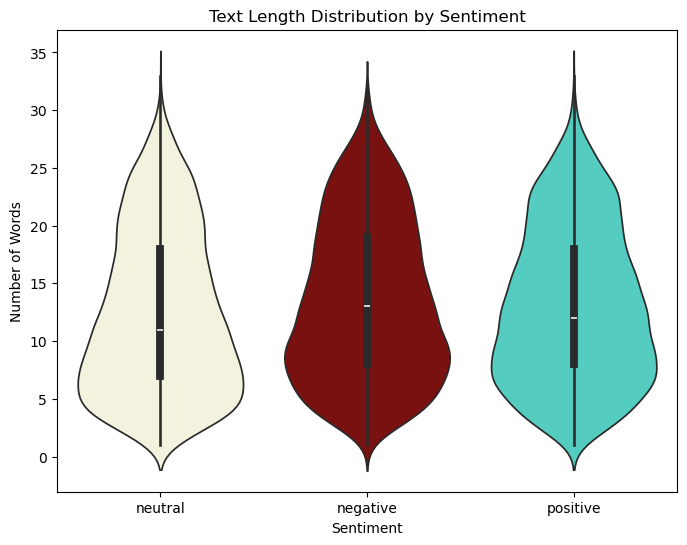

In [30]:
df['text_length'] = df['dirty_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,6))
sns.violinplot(x='sentiment', y='text_length', data=df, hue='sentiment', palette={'neutral':'beige', 'positive':'turquoise', 'negative':'darkred'})
plt.title('Text Length Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')
plt.show()

## Sentiment Analysis

Our first test evaluates pre-trained, rule-based sentiment engines. These systems require no training data but rely on static dictionaries. We deploy TextBlob and VADER (Valence Aware Dictionary and sEntiment Reasoner), mapping their continuous polarity scores to our discrete sentiment classes to establish a baseline performance metric.

In [33]:
def predictTextBlob(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        sentiment = 'positive'
    elif polarity < 0:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    return pd.Series([sentiment, polarity])

df[['TextBlob', 'TextBlob polarity']] = df['text'].apply(predictTextBlob)
df['TextBlob'].value_counts()

TextBlob
positive    14042
neutral     11058
negative     5809
Name: count, dtype: int64

In [35]:
anakin = SentimentIntensityAnalyzer()
def predictVADER(text):
    polarity = anakin.polarity_scores(text)['compound']
    if polarity >= 0.05:
        sentiment = 'positive'
    elif polarity <= -0.05:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    return pd.Series([sentiment, polarity])


df[['VADER', 'VADER polarity']] = df['text'].apply(predictVADER)
df['VADER'].value_counts()

VADER
positive    15755
neutral      8297
negative     6857
Name: count, dtype: int64

To determine if domain-adapted training outperforms static lexicons, we construct a supervised NLP pipeline. We vectorize the corpus using TF-IDF (restricted to a minimum document frequency of 5 to prune extreme outliers) and train a `LogisticRegression` classifier. To ensure a fair comparison against the zero-shot engines, we evaluate the ML model using its 5-fold cross-validation score.

In [37]:
X = df['text']
Y = df['sentiment']
vectorizer = TfidfVectorizer(min_df=5)
classifier = LogisticRegression(C=1, solver='saga', penalty= 'l1', random_state=42)
pipe = Pipeline([('vectorizer', vectorizer), ('classifier', classifier)])

Y_pred = cross_val_predict(pipe, X, Y, cv=5)
Y_proba = cross_val_predict(pipe, X, Y, cv=5, method='predict_proba')
df['Logistic Regression'] = Y_pred
df['Logistic Regression confidence'] = Y_proba.max(axis=1)
df['Logistic Regression'].value_counts()

Logistic Regression
neutral     15009
positive     8888
negative     7012
Name: count, dtype: int64

A final look into the populated dataframe.

In [39]:
df

,text,sentiment,dirty_text,text_length,TextBlob,TextBlob polarity,VADER,VADER polarity,Logistic Regression,Logistic Regression confidence
0,responded going,neutral,"I`d have responded, if I were going",7,neutral,0.00,neutral,0.0000,neutral,0.741667
1,sooo sad miss san diego,negative,Sooo SAD I will miss you here in San Diego!!!,10,negative,-0.50,negative,-0.5719,negative,0.959196
2,boss bullying,negative,my boss is bullying me...,5,neutral,0.00,negative,-0.5994,neutral,0.512794
3,interview leave alone,negative,what interview! leave me alone,5,neutral,0.00,negative,-0.2960,neutral,0.542754
4,sons put releases already bought,negative,"Sons of ****, why couldn`t they put them on the releases we already bought",14,neutral,0.00,neutral,0.0000,neutral,0.577608
...,...,...,...,...,...,...,...,...,...,...
3529,tired sleep try,negative,"its at 3 am, im very tired but i can`t sleep but i try it",15,negative,-0.40,negative,-0.4404,negative,0.841592
3530,alone old house thanks net keeps alive kicking whoever invented net wanna kiss hair,positive,"All alone in this old house again. Thanks for the net which keeps me alive and kicking! Whoever invented the net, i wanna kiss your hair!",26,positive,0.08,positive,0.7430,positive,0.440028
3531,know mean little dog sinking depression wants move someplace tropical,negative,I know what you mean. My little dog is sinking into depression... he wants to move someplace tropical,18,negative,-0.10,negative,-0.5325,neutral,0.598068
3532,sutra next youtube video gonna love videos,positive,_sutra what is your next youtube video gonna be about? I love your videos!,14,positive,0.25,positive,0.6369,positive,0.675306


## Model Evaluation

Let's store all results in a single dataframe so we can compare them later, and define our metrics.

In [42]:
results_df = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1-score"])
models = ['TextBlob', 'VADER', 'Logistic Regression']

def compute_metrics(Y, Y_pred):
    accuracy = accuracy_score(Y, Y_pred)
    precision = precision_score(Y, Y_pred, average='weighted')
    recall = recall_score(Y, Y_pred, average='weighted')
    f1 = f1_score(Y, Y_pred, average='weighted')
    return [accuracy, precision, recall, f1]

In [43]:
for model in models:
    Y_pred = df[model]
    results_df.loc[model] = compute_metrics(Y, Y_pred)

We compile Accuracy, Precision, Recall, and F1-Score into a unified evaluation matrix to directly compare them.

In [44]:
results_df

,Accuracy,Precision,Recall,F1-score
TextBlob,0.589763,0.604361,0.589763,0.582569
VADER,0.632049,0.667728,0.632049,0.624703
Logistic Regression,0.708434,0.718663,0.708434,0.708242


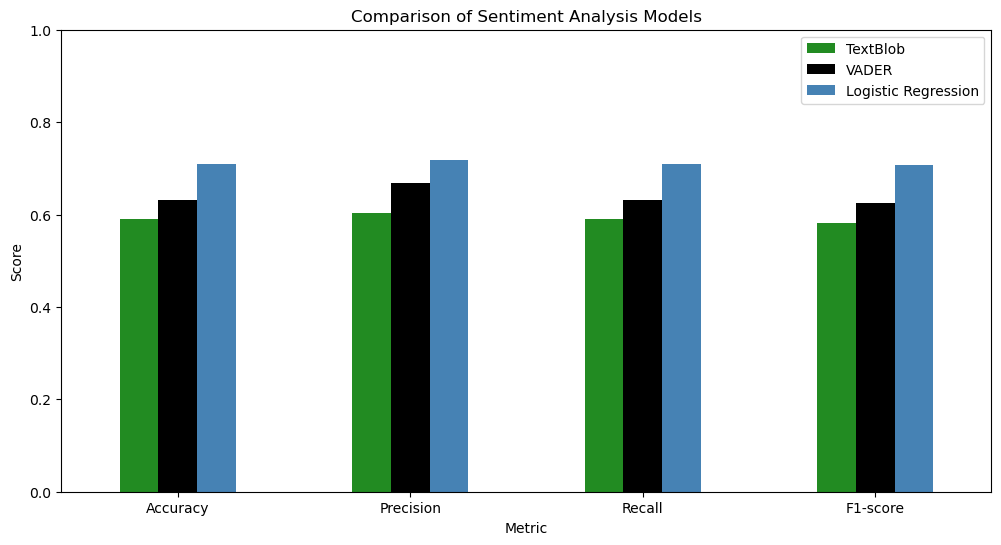

In [46]:
results_df.T.plot(kind='bar', figsize=(12, 6), color=['forestgreen','black','steelblue'])

plt.title('Comparison of Sentiment Analysis Models')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

Evaluating raw accuracy is insufficient. We must understand how safely the models make their predictions. The following distributions compare the polarity thresholds of the lexicon models against the probabilistic confidence of the Logistic Regression model.

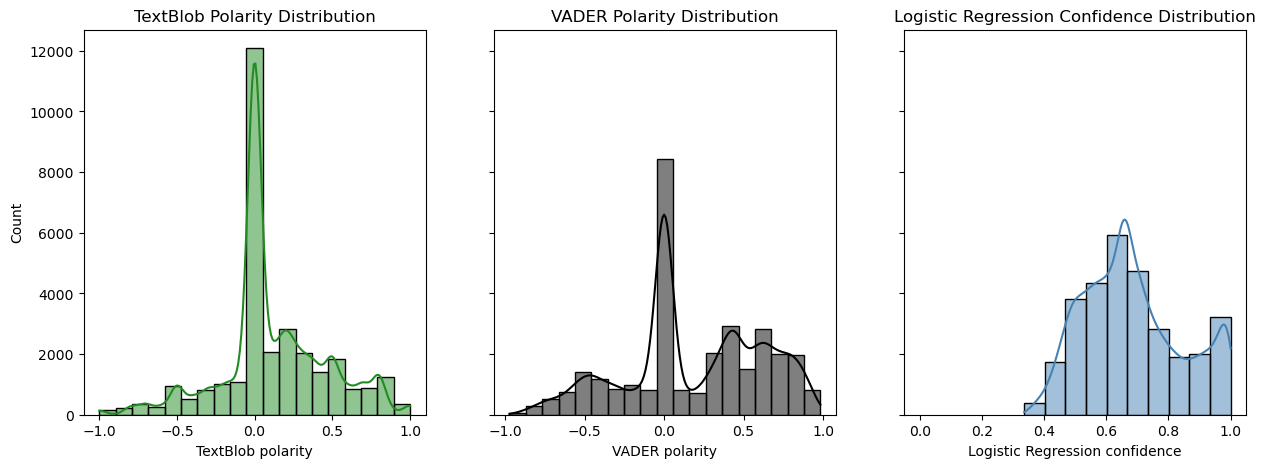

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

sns.histplot(df['TextBlob polarity'], bins=19, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('TextBlob Polarity Distribution')

sns.histplot(df['VADER polarity'], bins=19, kde=True, ax=axes[1], color='black')
axes[1].set_title('VADER Polarity Distribution')

sns.histplot(df['Logistic Regression confidence'], bins=10, kde=True, ax=axes[2], color='steelblue')
axes[2].set_title('Logistic Regression Confidence Distribution')
axes[2].set_xlim(-0.05, 1.05) 

plt.show()

To pinpoint exactly where the lexicon models fail, we render confusion matrices. This allows us to observe the specific misclassification pipelines, particularly the boundary where models struggle to differentiate between objective statements and nuanced sentiment.

_Note: The Logistic Regression matrix is intentionally omitted here. Because its predictions were generated via k-fold cross-validation, aggregating its out-of-fold errors alongside the static, zero-shot errors of the lexicons would be methodologically inconsistent._

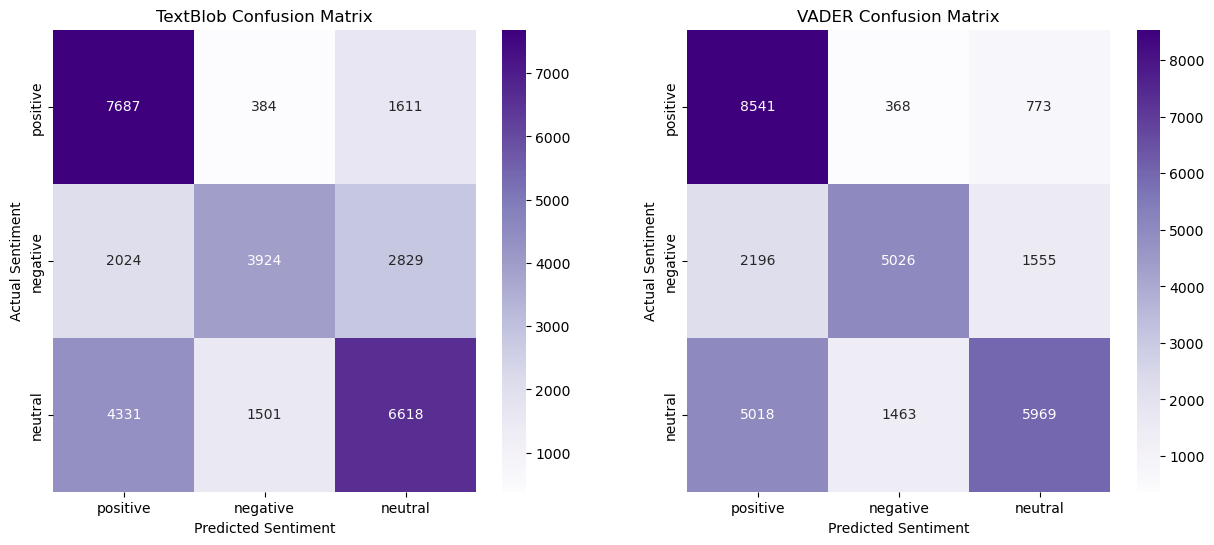

In [ ]:
models.pop() # Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for i, model in enumerate(models):
    Y_pred = df[model]
    cm = confusion_matrix(Y, Y_pred, labels=['positive', 'negative', 'neutral'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
                xticklabels=['positive', 'negative', 'neutral'], 
                yticklabels=['positive', 'negative', 'neutral'], 
                ax=axes[i])
    axes[i].set_xlabel('Predicted Sentiment')
    axes[i].set_ylabel('Actual Sentiment')
    axes[i].set_title(model + ' Confusion Matrix')
plt.show()

It is especially interesting to investigate the edge cases where all three models mathematically agreed, but were all incorrect. Especially interesting are the non-neutral cases.

In [52]:
agreed_prediction = (df['TextBlob'] == df['VADER']) & (df['VADER'] == df['Logistic Regression'])
wrong_prediction = (df['TextBlob'] != df['sentiment'])
nonneutral_prediction = (df['sentiment'] != 'neutral') & (df['TextBlob'] != 'neutral')

interesting = df[agreed_prediction & wrong_prediction & nonneutral_prediction]

interesting[['dirty_text', 'text', 'sentiment', 'TextBlob', 'VADER', 'Logistic Regression']]

,dirty_text,text,sentiment,TextBlob,VADER,Logistic Regression
76,"WOW, i AM REALLY MiSSiN THE FAM(iLY) TODAY. BADDD.",wow really missin fam ily today baddd,negative,positive,positive,positive
103,i realy wanted to go out cause its so nice but everybodys busy,realy wanted go cause nice everybodys busy,negative,positive,positive,positive
139,"missed all the awesome weather, because she was in a movie!",missed awesome weather movie,negative,positive,positive,positive
369,l`m on 3 days too matt. No fun this weekend.,l days matt fun weekend,negative,positive,positive,positive
381,I`m 25 in december that`s not good at all next big birthday is 30 after 21 it flys by for sure,december good next big birthday flys sure,negative,positive,positive,positive
...,...,...,...,...,...,...
3194,"_fan76 ROFL! THAT`S my problem, only two hands",fan rofl problem two hands,negative,positive,positive,positive
3217,"I forgot that was tonight! Was planning on heading down to the Cask, that might not be such a good idea",forgot tonight planning heading cask might good idea,negative,positive,positive,positive
3428,"I`m mo nudge you again, better watch out!",mo nudge better watch,negative,positive,positive,positive
3429,HOW COME ITS SO HARD TO FIND A GUY WITH THE SAME PASSION FOR LOVE AS FOR A WOMAN?? AM I EVER GOING TO SEE THE DAY! IM lonely yall!,come hard find guy passion love woman ever going see day lonely yall,negative,positive,positive,positive


## Final Thoughts

1. VADER Outperforms TextBlob. Within the realm of rule-based systems, VADER proved marginally superior for this dataset, likely due to its specific tuning for social media heuristics. However, both lexicons were frequently misclassifying neutral sentiments as positive.

2. The supervised `LogisticRegression` model significantly outperformed the static lexicons. Furthermore, its probabilistic confidence distribution was notably tighter (averaging ~70%), proving that training on domain-specific n-grams is highly preferable for noisy Twitter data.

3. Overall, the lexicons' confidence is fairly low, with many polarities being observed at or near zero. Analysis of their distributions reveals that both exhibit a systemic positive bias: higher predictive confidence when classifying positive sentiments. Because rule-based engines lack contextual awareness, they frequently misinterpret sarcasm or conditional complaints on social media (which often contain structurally "positive" words), leading to a highly inflated false-positive rate for the positive class.

4. Most critically, we observed unanimous model failures caused by naive stopword removal. By stripping words like "not" during preprocessing, we inadvertently destroyed semantic negation (e.g., transforming "not good" into a positive "good" feature). Takeaway: For future production deployments, the preprocessor must utilize a custom-curated stopword list that strictly preserves negation modifiers.

5. The word "work" seems to be prevelant in negative sentiment texts. 